# Diabetes Prediction System

Kaggle: https://www.kaggle.com/datasets/kumargh/pimaindiansdiabetescsv

The model: Logistic Regression.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

## 1. Load the data



In [25]:
df = pd.read_csv("../data/diabetes.csv")

print("Shape:", df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [26]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

## 2. Preprocess



In [27]:
missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

(df[missing] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [28]:
df[missing] = df[missing].replace(0, np.nan)

## 3. Split into train and test

- Training set (614 patients)
- Test set (154 patients) 

stratify=y is used to keep  healthy to diabetic ratio in both groups

In [29]:
X = df.drop("Outcome", axis=1)   # the 8 measurements
y = df["Outcome"]                # the answer

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])

Train: 614 | Test: 154


## 4. Fill the missing values

In [30]:
medians = X_train.median()   # from the 614 training patients only

X_train = X_train.fillna(medians)
X_test = X_test.fillna(medians)

print("Remaining missing values:", X_train.isna().sum().sum() + X_test.isna().sum().sum())

Remaining missing values: 0


## 4. Scale the features


In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # learn from training data
X_test_scaled = scaler.transform(X_test)        

## 5. Train the model


In [32]:
# without "balanced" the model favours the 500 healthy over the 268 diabetic with "balanced" 38 of 54 diabetics are caught instead of 27
model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)   # the yes/no answer

# [:, 1] picks the probability of diabetes rather than of no diabetes
y_prob = model.predict_proba(X_test_scaled)[:, 1]

## 6. Evaluate



In [33]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[75 25]
 [16 38]]


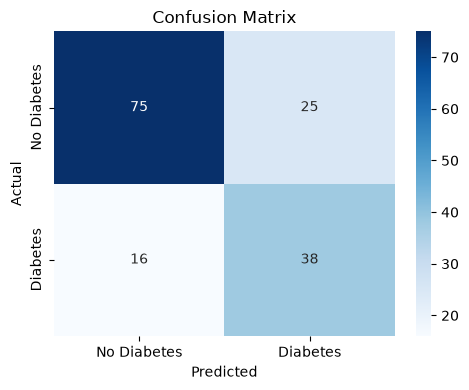

In [34]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

Of the 100 healthy patients 75 were correctly cleared and 25 were marked as diabetic by mistake because their glucose or BMI looks high. The model
only has 8 measurements to go with so people with similar numbers get the same answer.

Of the 54 diabetic patients 38 were caught and 16 were missed

In [35]:
print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob), 3))

              precision    recall  f1-score   support

 No Diabetes       0.82      0.75      0.79       100
    Diabetes       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154

ROC AUC: 0.813


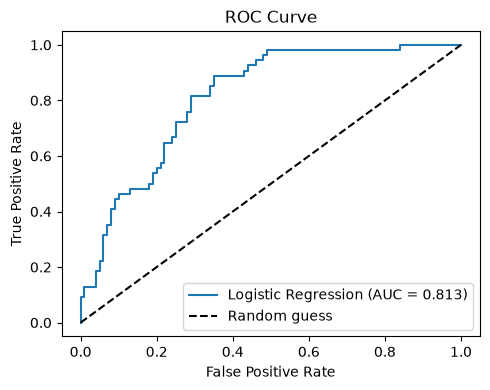

In [36]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label="Logistic Regression (AUC = %.3f)" % roc_auc_score(y_test, y_prob))
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Cut off


In [37]:
print("threshold   caught   missed   false alarms   precision   recall")
print("-" * 66)

for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    fg = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, fg).ravel()

    precision = tp / (tp + fp)   # how many really were diabetic
    recall = tp / (tp + fn)      # how many were caught

    current = "  <- current" if t == 0.5 else ""
    print("  %.0f%%        %2d/54     %2d       %2d/100         %.2f        %.2f%s"
          % (t * 100, tp, fn, fp, precision, recall, current))

threshold   caught   missed   false alarms   precision   recall
------------------------------------------------------------------
  30%        48/54      6       40/100         0.55        0.89
  40%        45/54      9       34/100         0.57        0.83
  50%        38/54     16       25/100         0.60        0.70  <- current
  60%        31/54     23       21/100         0.60        0.57
  70%        26/54     28       16/100         0.62        0.48
  80%        23/54     31        9/100         0.72        0.43


Kept the cut off at 50% as sklearn uses it by default as going lower would catch more diabetic but mark more healthy people as diabetic

## 8. Feature importance



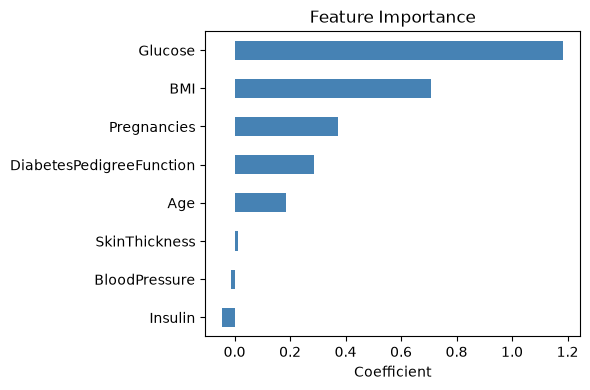

Glucose                     1.183483
BMI                         0.709592
Pregnancies                 0.372902
DiabetesPedigreeFunction    0.287734
Age                         0.186434
SkinThickness               0.013980
BloodPressure              -0.014612
Insulin                    -0.044609
dtype: float64

In [38]:
importance = pd.Series(model.coef_[0], index=X.columns).sort_values()

plt.figure(figsize=(6, 4))
importance.plot(kind="barh", color="steelblue")
plt.xlabel("Coefficient")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

importance.sort_values(ascending=False)

In [39]:
# patients 7, 4 and 3: one caught, one cleared, one missed
for i in [3, 4, 7]:
    patient = X_test.iloc[i]
    prediction = "Diabetes" if y_pred[i] == 1 else "No Diabetes"
    actual = "Diabetes" if y_test.iloc[i] == 1 else "No Diabetes"

    print("Patient", i)
    print("  Input :")

    # print each measurement on its own line
    for name, value in patient.items():
        print("    %s = %g" % (name, value))

    print("  Output:", prediction, "(risk %.1f%%)" % (y_prob[i] * 100))
    print("  Actual:", actual)
    print()

Patient 3
  Input :
    Pregnancies = 7
    Glucose = 114
    BloodPressure = 64
    SkinThickness = 29
    Insulin = 125
    BMI = 27.4
    DiabetesPedigreeFunction = 0.732
    Age = 34
  Output: No Diabetes (risk 38.3%)
  Actual: Diabetes

Patient 4
  Input :
    Pregnancies = 2
    Glucose = 74
    BloodPressure = 72
    SkinThickness = 29
    Insulin = 125
    BMI = 32.4
    DiabetesPedigreeFunction = 0.102
    Age = 22
  Output: No Diabetes (risk 5.5%)
  Actual: No Diabetes

Patient 7
  Input :
    Pregnancies = 8
    Glucose = 197
    BloodPressure = 74
    SkinThickness = 29
    Insulin = 125
    BMI = 25.9
    DiabetesPedigreeFunction = 1.191
    Age = 39
  Output: Diabetes (risk 96.2%)
  Actual: Diabetes



In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from xgboost import XGBClassifier

X_all = X.fillna(X_train.median())
cv = StratifiedKFold(5, shuffle=True, random_state=42)

candidates = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42,
                                              class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42,
                                            class_weight="balanced"),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=3, random_state=42,
                             scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
                             eval_metric="logloss"),
}

for name, candidate in candidates.items():
    scores = cross_val_score(candidate, StandardScaler().fit_transform(X_all), y,
                             cv=cv, scoring="roc_auc")
    print("%-20s AUC: %.3f (+/- %.3f)" % (name, scores.mean(), scores.std()))

Logistic Regression  AUC: 0.836 (+/- 0.020)
Random Forest        AUC: 0.828 (+/- 0.019)
XGBoost              AUC: 0.795 (+/- 0.034)
